In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math

In [2]:
sim = Simulation("NaturalVignetting")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable natural vignetting

sim["CCD/IncludeNaturalVignetting"] = "yes"

output = sim.run(removeOutputFile = True)


2019-11-06 14:33:17 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-06 14:33:17 WARNING Camera: No star positions to write to HDF5 file.



In [6]:
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]

In [3]:
image = output.getImage(0)

# Normisation of the image

image /= image[0][0]

(0, 0.16)

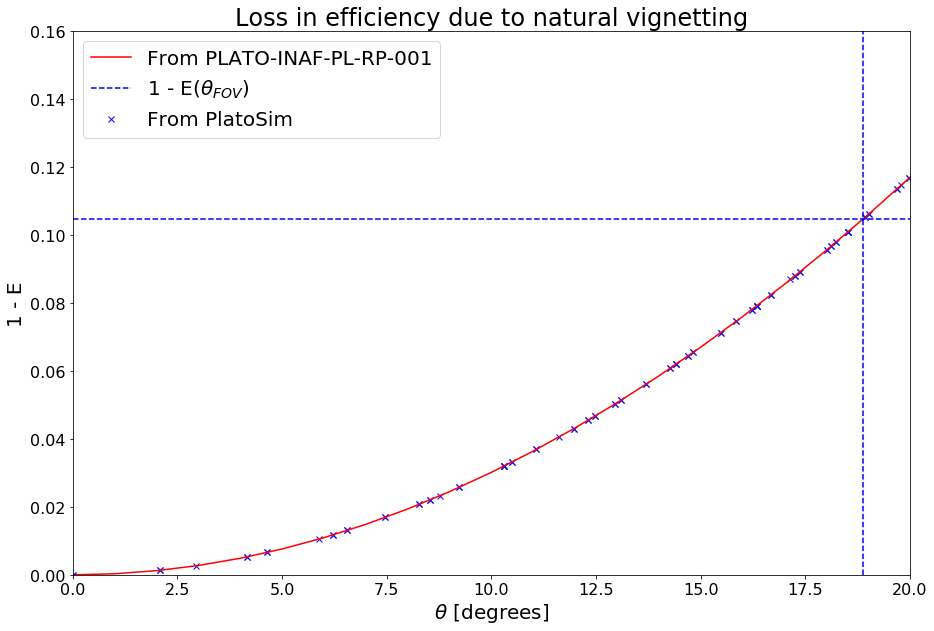

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

for row in range(0, sim["SubField/NumRows"], 500):
    
    for column in range(0, sim["SubField/NumColumns"], 500):
        
        # Calculate the angular distance of pixel (row, column) from the optical axis
        
        xFP, yFP = rf.pixelToFocalPlaneCoordinates(column, row, sim["CCD/PixelSize"], 0, 0, 0)     # Focal-plane coordinates[mm]
        distance = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, sim["Camera/FocalLength/ConstantValue"] * 1000))     # Angular distance from the OA [degrees]
        
        try:
            plt.plot([distance], 1 - image[row][column], "bx")
        except:
            pass

        

###########################
# From PLATO-INAF-PL-RP-001
###########################

radialDistances = np.arange(25)
plt.plot(radialDistances, np.sin(np.deg2rad(radialDistances))**2 / np.sin(np.deg2rad(fovDegrees))**2 * 0.1048, "r", label = "From PLATO-INAF-PL-RP-001")



###########################################################
# Edge of the FOV (θ = 18.8876°): efficiency loss of 10.48%
###########################################################

plt.axvline(x = 18.8908, color = "b", linestyle = "--")
plt.axhline(y = 0.1048, color = "b", linestyle = "--", label = "1 - E($\\theta_{FOV}$)")



########
# Layout
########

plt.title("Loss in efficiency due to natural vignetting", fontsize = 24)
plt.xlabel("$\\theta$ [degrees]", fontsize = 20)
plt.ylabel("1 - E", fontsize = 20)

plt.plot([0], [0], "bx", label = "From PlatoSim")
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.xlim([0,20])
plt.ylim([0, 0.16])